In [1]:
# Phase 18 – Ablation Study | Cell 1: Setup

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sys
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase18"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9" / "models"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11" / "models"

print("=" * 60)
print("Phase 18 – Ablation Study | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Variants: Full | no_SR | no_GraphSAGE | no_StageI | no_StageII | no_PPO | no_TD3 | no_ShockEngine")

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv
from stable_baselines3 import PPO, TD3

base_features = np.load(P8 / "base_features.npy")
emb_gs = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

# optional TGN/zero emb for ablation
emb_zero = np.zeros_like(emb_gs)
if (P8 / "emb_TGN.npy").exists():
    emb_tgn = np.load(P8 / "emb_TGN.npy")
else:
    emb_tgn = emb_zero

ppo_path = P9 / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    ppo_path = P9 / "PPO_moderate.zip"
ppo_model = PPO.load(str(ppo_path))

td3 = {}
for s in ["standard", "strong"]:
    p = P11 / f"TD3_{s}_r.zip"
    if not p.exists():
        p = P11 / f"TD3_{s}.zip"
    td3[s] = TD3.load(str(p))

print(f"base_features {base_features.shape} | emb {emb_gs.shape} | sr {sr_vector.shape}")
print("Models: PPO + TD3 standard/strong loaded")
print("Cell 1 completed successfully.")

Phase 18 – Ablation Study | Cell 1
Timestamp : 2026-10-06 09:38:37
Variants: Full | no_SR | no_GraphSAGE | no_StageI | no_StageII | no_PPO | no_TD3 | no_ShockEngine
base_features (378, 16) | emb (378, 32) | sr (378,)
Models: PPO + TD3 standard/strong loaded
Cell 1 completed successfully.


Phase 18 – Cell 2: Ablation evaluation
standard | BankingCrisis /Moderate | Full           | R=31.927 | SR=1.498
standard | BankingCrisis /Moderate | no_SR          | R=36.986 | SR=1.496
standard | BankingCrisis /Moderate | no_GraphSAGE   | R=31.927 | SR=1.498
standard | BankingCrisis /Moderate | no_StageI      | R=28.974 | SR=1.498
standard | BankingCrisis /Moderate | no_StageII     | R=14.746 | SR=0.845
standard | BankingCrisis /Moderate | no_PPO         | R=14.751 | SR=1.413
standard | BankingCrisis /Moderate | no_TD3         | R=14.777 | SR=0.823
standard | BankingCrisis /Moderate | no_ShockEngine | R=31.927 | SR=1.498
standard | BankingCrisis /Severe   | Full           | R=31.927 | SR=1.498
standard | BankingCrisis /Severe   | no_SR          | R=36.986 | SR=1.496
standard | BankingCrisis /Severe   | no_GraphSAGE   | R=31.927 | SR=1.498
standard | BankingCrisis /Severe   | no_StageI      | R=28.974 | SR=1.498
standard | BankingCrisis /Severe   | no_StageII     | R=13.769 | SR=0.774

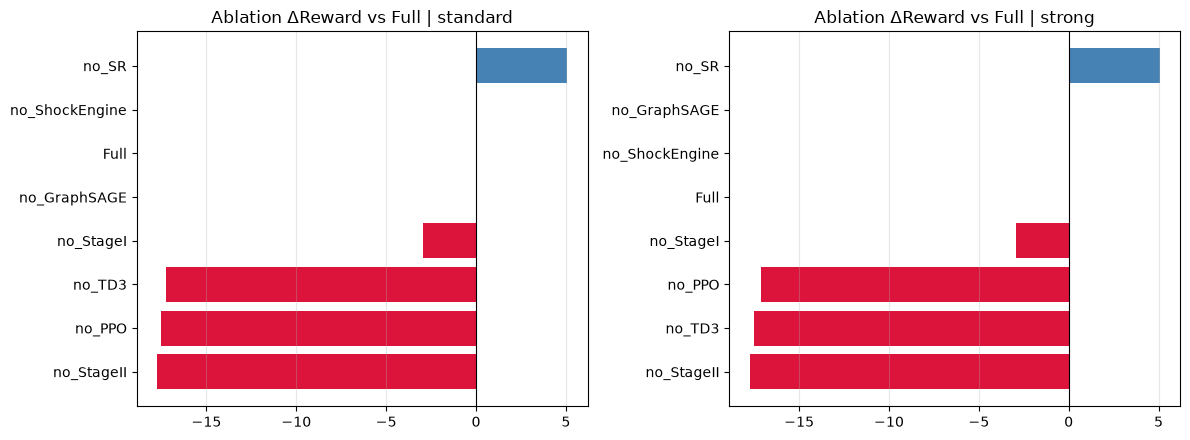


Cell 2 completed successfully.
PHASE 18 COMPLETED.


In [2]:
# Phase 18 – Cell 2: Run all ablation variants

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase18" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase18" / "figures"

print("=" * 60)
print("Phase 18 – Cell 2: Ablation evaluation")
print("=" * 60)

STAGE1, STAGE2 = 10, 30
N_EP, SEEDS = 8, [0, 1]
SERIES_LIST = ["standard", "strong"]
FOCUS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Severe"),
]

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def act_ppo(obs, env):
    a, _ = ppo_model.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return a[:adim]

def act_td3(obs, series, env):
    a, _ = td3[series].predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        tax, sub, rate, qe, credit, risk = a[:6]
        base = np.array([tax, 0.5*sub+0.3*qe, 0.4*qe+0.3*risk, 0.5*credit+0.2*rate], dtype=np.float32)
        a = base
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

def act_random(env):
    return env.action_space.sample()

def make_env(series, emb_use, sr_use, seed, shock_type=None, severity=None, use_shock_on_reset=False):
    # sr ablation: zeros
    sr = sr_use
    env = ShockEconomicsEnv(
        base_features, emb_use, sr, panel, nodes,
        level="moderate",
        shock_type=shock_type if use_shock_on_reset else None,
        severity=severity if use_shock_on_reset else None,
        shock_series=series,
        seed=seed,
    )
    return env

VARIANTS = [
    "Full",
    "no_SR",
    "no_GraphSAGE",
    "no_StageI",
    "no_StageII",
    "no_PPO",
    "no_TD3",
    "no_ShockEngine",
]

rows = []

for series in SERIES_LIST:
    for st, sev in FOCUS:
        for variant in VARIANTS:
            ep_R, ep_SR = [], []
            for seed in SEEDS:
                for ep in range(N_EP):
                    sid = seed * 1000 + ep

                    # embedding choice
                    emb_use = emb_zero if variant == "no_GraphSAGE" else emb_gs
                    # SR choice
                    sr_use = np.zeros_like(sr_vector) if variant == "no_SR" else sr_vector

                    env = make_env(series, emb_use, sr_use, sid)
                    obs, _ = env.reset(seed=sid)
                    total_r = 0.0

                    apply_shock = variant != "no_ShockEngine"

                    if variant == "Full":
                        # hierarchical: StageI PPO then shock then StageII TD3
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break
                        if apply_shock and hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    elif variant == "no_SR":
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break
                        if apply_shock and hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    elif variant == "no_GraphSAGE":
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break
                        if apply_shock and hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    elif variant == "no_StageI":
                        # only StageII after shock
                        if apply_shock and hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE1 + STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    elif variant == "no_StageII":
                        # only StageI then shock then random residual
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break
                        if apply_shock and hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_random(env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    elif variant == "no_PPO":
                        # StageI random, StageII TD3
                        for _ in range(STAGE1):
                            a = act_random(env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break
                        if apply_shock and hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    elif variant == "no_TD3":
                        # StageI PPO, StageII random
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break
                        if apply_shock and hasattr(env, "apply_shock"):
                            env.apply_shock(st, sev, series)
                            obs = rebuild_obs(env)
                        for _ in range(STAGE2):
                            a = act_random(env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    elif variant == "no_ShockEngine":
                        # hierarchical actions but never apply shock
                        for _ in range(STAGE1):
                            a = act_ppo(obs, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break
                        for _ in range(STAGE2):
                            a = act_td3(obs, series, env)
                            obs, r, term, trunc, _ = env.step(a)
                            total_r += float(r)
                            if term or trunc:
                                break

                    ep_R.append(total_r)
                    ep_SR.append(get_sr(env))

            rows.append({
                "series": series,
                "shock_type": st,
                "severity": sev,
                "variant": variant,
                "mean_reward": float(np.mean(ep_R)),
                "std_reward": float(np.std(ep_R)),
                "mean_sr_end": float(np.mean(ep_SR)),
                "std_sr_end": float(np.std(ep_SR)),
            })
            print(f"{series:8s} | {st:14s}/{sev:8s} | {variant:14s} | "
                  f"R={rows[-1]['mean_reward']:.3f} | SR={rows[-1]['mean_sr_end']:.3f}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase18_ablation_raw.csv", index=False)

# aggregate over shocks
agg = (
    df.groupby(["series", "variant"], as_index=False)
      .agg(
          mean_reward=("mean_reward", "mean"),
          std_reward=("mean_reward", "std"),
          mean_sr=("mean_sr_end", "mean"),
          std_sr=("mean_sr_end", "std"),
      )
)
agg.to_csv(OUT_TAB / "phase18_ablation_summary.csv", index=False)
print("\n=== Summary ===")
print(agg.sort_values(["series", "mean_reward"], ascending=[True, False]).to_string(index=False))

# delta vs Full
cmp = []
for series in SERIES_LIST:
    sub = agg[agg.series == series]
    full = sub[sub.variant == "Full"].iloc[0]
    for _, row in sub.iterrows():
        cmp.append({
            "series": series,
            "variant": row.variant,
            "mean_reward": row.mean_reward,
            "delta_reward_vs_full": float(row.mean_reward - full.mean_reward),
            "mean_sr": row.mean_sr,
            "delta_sr_vs_full": float(row.mean_sr - full.mean_sr),
        })
cmp = pd.DataFrame(cmp)
cmp.to_csv(OUT_TAB / "phase18_ablation_vs_full.csv", index=False)
print("\n=== vs Full ===")
print(cmp.sort_values(["series", "delta_reward_vs_full"]).to_string(index=False))

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series in zip(axes, SERIES_LIST):
    sub = cmp[cmp.series == series].copy()
    # order by delta ascending (worst drop first) but keep Full visible
    sub = sub.sort_values("delta_reward_vs_full")
    colors = ["seagreen" if v == "Full" else "crimson" if d < -1 else "steelblue"
              for v, d in zip(sub["variant"], sub["delta_reward_vs_full"])]
    ax.barh(sub["variant"], sub["delta_reward_vs_full"], color=colors)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"Ablation ΔReward vs Full | {series}")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase18_ablation_delta_reward.png", dpi=150)
plt.show()

print("\nCell 2 completed successfully.")
print("PHASE 18 COMPLETED.")

Phase 18 – Cell 3B: Retrain w/o GraphSAGE | steps=30000
StageI env: EconomicsNetworkEnv

--- PPO Full (GraphSAGE) | 30000 ---
--- PPO no_GraphSAGE | 30000 ---
--- TD3 Full (GraphSAGE) | 30000 ---
--- TD3 no_GraphSAGE | 30000 ---
Training done.
Full_retrain_GS        | BankingCrisis /Moderate | R=32.800 | SR=1.496
Full_retrain_GS        | BankingCrisis /Severe   | R=32.800 | SR=1.496
Full_retrain_GS        | Recession     /Moderate | R=32.800 | SR=1.496
Full_retrain_GS        | DebtCrisis    /Severe   | R=32.800 | SR=1.496
no_GraphSAGE_retrain   | BankingCrisis /Moderate | R=32.258 | SR=1.496
no_GraphSAGE_retrain   | BankingCrisis /Severe   | R=32.258 | SR=1.496
no_GraphSAGE_retrain   | Recession     /Moderate | R=32.258 | SR=1.496
no_GraphSAGE_retrain   | DebtCrisis    /Severe   | R=32.258 | SR=1.496

=== GraphSAGE ablation | 30k equal budget ===
             variant  mean_reward  mean_sr  std_reward
     Full_retrain_GS    32.800460 1.496413         0.0
no_GraphSAGE_retrain    32.2575

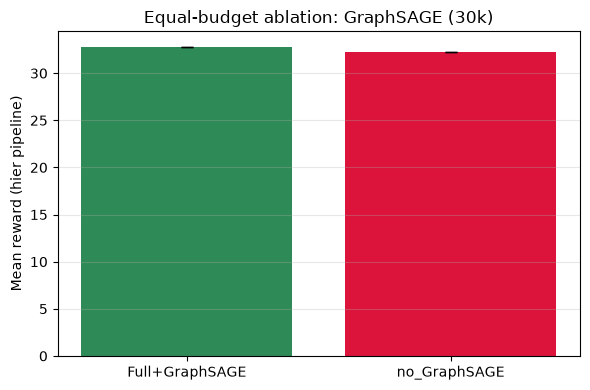


Cell 3B completed successfully.


In [3]:
# Phase 18 – Cell 3B: Retrain without GraphSAGE | budget = 30000 (same as Phase 9/11)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, TD3
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.noise import NormalActionNoise

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase18" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase18" / "figures"
OUT_MODEL = PROJECT / "outputs" / "phase18" / "models"
OUT_MODEL.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 18 – Cell 3B: Retrain w/o GraphSAGE | steps=30000")
print("=" * 60)

TIMESTEPS = 30000          # equal to Phase 9 / 11
EVAL_EP = 10
SEEDS_EVAL = [0, 1]
SERIES = "standard"

emb_no = np.zeros_like(emb_gs)

def make_shock_env(emb_use, series="standard", seed=0, shock=True):
    return ShockEconomicsEnv(
        base_features, emb_use, sr_vector, panel, nodes,
        level="moderate",
        shock_type="BankingCrisis" if shock else None,
        severity="Moderate" if shock else None,
        shock_series=series,
        seed=seed,
    )

try:
    from economics_env import EconomicsNetworkEnv
    def make_stage1_env(emb_use, seed=0):
        return EconomicsNetworkEnv(
            base_features, emb_use, sr_vector, panel, nodes,
            level="moderate", seed=seed,
        )
    print("StageI env: EconomicsNetworkEnv")
except Exception:
    def make_stage1_env(emb_use, seed=0):
        return make_shock_env(emb_use, seed=seed, shock=False)
    print("StageI env: ShockEnv(no shock)")

# ----- PPO -----
print("\n--- PPO Full (GraphSAGE) | 30000 ---")
env = DummyVecEnv([lambda: make_stage1_env(emb_gs, 0)])
ppo_full = PPO("MlpPolicy", env, verbose=0, seed=0, learning_rate=3e-4, gamma=0.99)
ppo_full.learn(TIMESTEPS)
ppo_full.save(str(OUT_MODEL / "PPO_with_GraphSAGE_30k"))

print("--- PPO no_GraphSAGE | 30000 ---")
env = DummyVecEnv([lambda: make_stage1_env(emb_no, 0)])
ppo_no = PPO("MlpPolicy", env, verbose=0, seed=0, learning_rate=3e-4, gamma=0.99)
ppo_no.learn(TIMESTEPS)
ppo_no.save(str(OUT_MODEL / "PPO_no_GraphSAGE_30k"))

# ----- TD3 -----
n_act = DummyVecEnv([lambda: make_shock_env(emb_gs, SERIES, 0, True)]).action_space.shape[0]
noise = NormalActionNoise(mean=np.zeros(n_act), sigma=0.1 * np.ones(n_act))

print("--- TD3 Full (GraphSAGE) | 30000 ---")
env = DummyVecEnv([lambda: make_shock_env(emb_gs, SERIES, 0, True)])
td3_full = TD3("MlpPolicy", env, verbose=0, seed=0, learning_rate=3e-4, gamma=0.99,
               tau=0.005, action_noise=noise)
td3_full.learn(TIMESTEPS)
td3_full.save(str(OUT_MODEL / "TD3_with_GraphSAGE_30k"))

print("--- TD3 no_GraphSAGE | 30000 ---")
env = DummyVecEnv([lambda: make_shock_env(emb_no, SERIES, 0, True)])
td3_no = TD3("MlpPolicy", env, verbose=0, seed=0, learning_rate=3e-4, gamma=0.99,
             tau=0.005, action_noise=noise)
td3_no.learn(TIMESTEPS)
td3_no.save(str(OUT_MODEL / "TD3_no_GraphSAGE_30k"))

print("Training done.")

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def run_hier(ppo, td3m, emb_use, shock_type, severity, series, seed):
    env = make_shock_env(emb_use, series, seed, shock=False)
    obs, _ = env.reset(seed=seed)
    R = 0.0
    for _ in range(10):
        a, _ = ppo.predict(obs, deterministic=True)
        a = np.asarray(a, dtype=np.float32).reshape(-1)
        adim = env.action_space.shape[0]
        if a.size < adim:
            a = np.pad(a, (0, adim - a.size))
        obs, r, term, trunc, _ = env.step(a[:adim])
        R += float(r)
        if term or trunc:
            break
    if hasattr(env, "apply_shock"):
        env.apply_shock(shock_type, severity, series)
        obs = rebuild_obs(env)
    for _ in range(30):
        a, _ = td3m.predict(obs, deterministic=True)
        a = np.asarray(a, dtype=np.float32).reshape(-1)
        adim = env.action_space.shape[0]
        if a.size >= 6:
            tax, sub, rate, qe, credit, risk = a[:6]
            a = np.array([tax, 0.5*sub+0.3*qe, 0.4*qe+0.3*risk, 0.5*credit+0.2*rate], dtype=np.float32)
        if a.size < adim:
            a = np.pad(a, (0, adim - a.size))
        obs, r, term, trunc, _ = env.step(np.clip(a[:adim], -1, 1))
        R += float(r)
        if term or trunc:
            break
    return R, get_sr(env)

FOCUS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Severe"),
]

rows = []
for label, ppo_m, td3_m, emb_use in [
    ("Full_retrain_GS", ppo_full, td3_full, emb_gs),
    ("no_GraphSAGE_retrain", ppo_no, td3_no, emb_no),
]:
    for st, sev in FOCUS:
        Rs, SRs = [], []
        for seed in SEEDS_EVAL:
            for ep in range(EVAL_EP):
                r, sr = run_hier(ppo_m, td3_m, emb_use, st, sev, SERIES, seed * 1000 + ep)
                Rs.append(r); SRs.append(sr)
        rows.append({
            "variant": label,
            "shock_type": st,
            "severity": sev,
            "mean_reward": float(np.mean(Rs)),
            "std_reward": float(np.std(Rs)),
            "mean_sr": float(np.mean(SRs)),
            "std_sr": float(np.std(SRs)),
        })
        print(f"{label:22s} | {st:14s}/{sev:8s} | R={rows[-1]['mean_reward']:.3f} | SR={rows[-1]['mean_sr']:.3f}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase18_graphsage_retrain30k_raw.csv", index=False)

summary = (
    df.groupby("variant", as_index=False)
      .agg(mean_reward=("mean_reward", "mean"),
           mean_sr=("mean_sr", "mean"),
           std_reward=("mean_reward", "std"))
)
summary.to_csv(OUT_TAB / "phase18_graphsage_retrain30k_summary.csv", index=False)

full = summary[summary.variant == "Full_retrain_GS"].iloc[0]
no = summary[summary.variant == "no_GraphSAGE_retrain"].iloc[0]
delta = {
    "timesteps": TIMESTEPS,
    "delta_reward": float(no.mean_reward - full.mean_reward),
    "delta_sr": float(no.mean_sr - full.mean_sr),
    "full_reward": float(full.mean_reward),
    "no_gs_reward": float(no.mean_reward),
    "full_sr": float(full.mean_sr),
    "no_gs_sr": float(no.mean_sr),
}
print("\n=== GraphSAGE ablation | 30k equal budget ===")
print(summary.to_string(index=False))
print("\nDelta (no_GS - Full):", delta)
pd.DataFrame([delta]).to_csv(OUT_TAB / "phase18_graphsage_retrain30k_delta.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Full+GraphSAGE", "no_GraphSAGE"], [full.mean_reward, no.mean_reward],
       color=["seagreen", "crimson"], yerr=[full.std_reward, no.std_reward], capsize=4)
ax.set_ylabel("Mean reward (hier pipeline)")
ax.set_title("Equal-budget ablation: GraphSAGE (30k)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase18_graphsage_retrain30k.png", dpi=150)
plt.show()

print("\nCell 3B completed successfully.")

Phase 18 – Cell 3C: Official vs retrain comparison
official_Full_GS           | BankingCrisis /Moderate | R=31.918 | SR=1.496
official_Full_GS           | BankingCrisis /Severe   | R=31.918 | SR=1.496
official_Full_GS           | Recession     /Moderate | R=31.918 | SR=1.496
official_Full_GS           | DebtCrisis    /Severe   | R=31.918 | SR=1.496
retrain_Full_GS_30k        | BankingCrisis /Moderate | R=32.800 | SR=1.496
retrain_Full_GS_30k        | BankingCrisis /Severe   | R=32.800 | SR=1.496
retrain_Full_GS_30k        | Recession     /Moderate | R=32.800 | SR=1.496
retrain_Full_GS_30k        | DebtCrisis    /Severe   | R=32.800 | SR=1.496
retrain_no_GraphSAGE_30k   | BankingCrisis /Moderate | R=32.258 | SR=1.496
retrain_no_GraphSAGE_30k   | BankingCrisis /Severe   | R=32.258 | SR=1.496
retrain_no_GraphSAGE_30k   | Recession     /Moderate | R=32.258 | SR=1.496
retrain_no_GraphSAGE_30k   | DebtCrisis    /Severe   | R=32.258 | SR=1.496

=== Summary ===
               model_set  mean_r

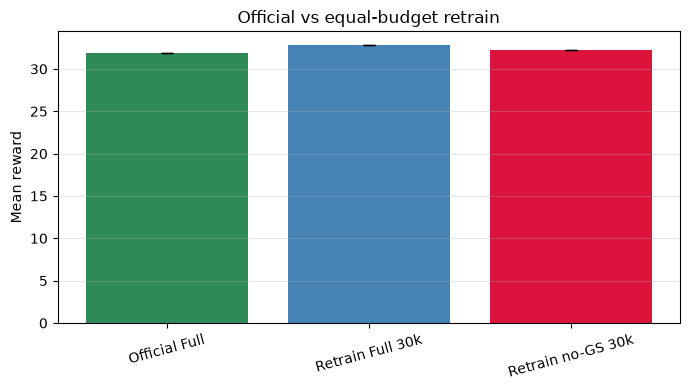


Cell 3C completed successfully.


In [4]:
# Phase 18 – Cell 3C: Compare new models vs official Phase9/11 models

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, TD3

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P9 = PROJECT / "outputs" / "phase9" / "models"
P11 = PROJECT / "outputs" / "phase11" / "models"
OUT_TAB = PROJECT / "outputs" / "phase18" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase18" / "figures"
OUT_MODEL = PROJECT / "outputs" / "phase18" / "models"

print("=" * 60)
print("Phase 18 – Cell 3C: Official vs retrain comparison")
print("=" * 60)

# official models
ppo_off_path = P9 / "PPO_moderate_gs.zip"
if not ppo_off_path.exists():
    ppo_off_path = P9 / "PPO_moderate.zip"
ppo_official = PPO.load(str(ppo_off_path))

td3_official = {}
for s in ["standard", "strong"]:
    p = P11 / f"TD3_{s}_r.zip"
    if not p.exists():
        p = P11 / f"TD3_{s}.zip"
    td3_official[s] = TD3.load(str(p))

# newly trained (from Cell 3B)
ppo_full_new = PPO.load(str(OUT_MODEL / "PPO_with_GraphSAGE_30k"))
ppo_nogs_new = PPO.load(str(OUT_MODEL / "PPO_no_GraphSAGE_30k"))
td3_full_new = TD3.load(str(OUT_MODEL / "TD3_with_GraphSAGE_30k"))
td3_nogs_new = TD3.load(str(OUT_MODEL / "TD3_no_GraphSAGE_30k"))

SERIES = "standard"
EVAL_EP = 10
SEEDS = [0, 1]
FOCUS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Severe"),
]
emb_no = np.zeros_like(emb_gs)

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb_m = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb_m.mean(axis=0) if emb_m.ndim == 2 else emb_m.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def make_env(emb_use, seed=0):
    return ShockEconomicsEnv(
        base_features, emb_use, sr_vector, panel, nodes,
        level="moderate", shock_type=None, severity=None,
        shock_series=SERIES, seed=seed,
    )

def act_td3(model, obs, env):
    a, _ = model.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        tax, sub, rate, qe, credit, risk = a[:6]
        a = np.array([tax, 0.5*sub+0.3*qe, 0.4*qe+0.3*risk, 0.5*credit+0.2*rate], dtype=np.float32)
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

def run_hier(ppo, td3m, emb_use, shock_type, severity, seed):
    env = make_env(emb_use, seed)
    obs, _ = env.reset(seed=seed)
    R = 0.0
    for _ in range(10):
        a, _ = ppo.predict(obs, deterministic=True)
        a = np.asarray(a, dtype=np.float32).reshape(-1)
        adim = env.action_space.shape[0]
        if a.size < adim:
            a = np.pad(a, (0, adim - a.size))
        obs, r, term, trunc, _ = env.step(a[:adim])
        R += float(r)
        if term or trunc:
            break
    if hasattr(env, "apply_shock"):
        env.apply_shock(shock_type, severity, SERIES)
        obs = rebuild_obs(env)
    for _ in range(30):
        a = act_td3(td3m, obs, env)
        obs, r, term, trunc, _ = env.step(a)
        R += float(r)
        if term or trunc:
            break
    return R, get_sr(env)

configs = [
    ("official_Full_GS", ppo_official, td3_official[SERIES], emb_gs),
    ("retrain_Full_GS_30k", ppo_full_new, td3_full_new, emb_gs),
    ("retrain_no_GraphSAGE_30k", ppo_nogs_new, td3_nogs_new, emb_no),
]

rows = []
for name, ppo_m, td3_m, emb_use in configs:
    for st, sev in FOCUS:
        Rs, SRs = [], []
        for seed in SEEDS:
            for ep in range(EVAL_EP):
                r, sr = run_hier(ppo_m, td3_m, emb_use, st, sev, seed * 1000 + ep)
                Rs.append(r); SRs.append(sr)
        rows.append({
            "model_set": name,
            "shock_type": st,
            "severity": sev,
            "mean_reward": float(np.mean(Rs)),
            "std_reward": float(np.std(Rs)),
            "mean_sr": float(np.mean(SRs)),
            "std_sr": float(np.std(SRs)),
        })
        print(f"{name:26s} | {st:14s}/{sev:8s} | R={rows[-1]['mean_reward']:.3f} | SR={rows[-1]['mean_sr']:.3f}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase18_official_vs_retrain_raw.csv", index=False)

summary = (
    df.groupby("model_set", as_index=False)
      .agg(mean_reward=("mean_reward", "mean"),
           mean_sr=("mean_sr", "mean"),
           std_reward=("mean_reward", "std"))
)
summary.to_csv(OUT_TAB / "phase18_official_vs_retrain_summary.csv", index=False)
print("\n=== Summary ===")
print(summary.to_string(index=False))

off = summary[summary.model_set == "official_Full_GS"].iloc[0]
ret = summary[summary.model_set == "retrain_Full_GS_30k"].iloc[0]
nogs = summary[summary.model_set == "retrain_no_GraphSAGE_30k"].iloc[0]

cmp = pd.DataFrame([
    {
        "comparison": "retrain_Full - official",
        "delta_reward": float(ret.mean_reward - off.mean_reward),
        "delta_sr": float(ret.mean_sr - off.mean_sr),
    },
    {
        "comparison": "retrain_noGS - official",
        "delta_reward": float(nogs.mean_reward - off.mean_reward),
        "delta_sr": float(nogs.mean_sr - off.mean_sr),
    },
    {
        "comparison": "retrain_noGS - retrain_Full",
        "delta_reward": float(nogs.mean_reward - ret.mean_reward),
        "delta_sr": float(nogs.mean_sr - ret.mean_sr),
    },
])
cmp.to_csv(OUT_TAB / "phase18_official_vs_retrain_delta.csv", index=False)
print("\n=== Deltas ===")
print(cmp.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
order = ["official_Full_GS", "retrain_Full_GS_30k", "retrain_no_GraphSAGE_30k"]
sub = summary.set_index("model_set").loc[order]
ax.bar(range(3), sub["mean_reward"], yerr=sub["std_reward"], capsize=4,
       color=["seagreen", "steelblue", "crimson"])
ax.set_xticks(range(3))
ax.set_xticklabels(["Official Full", "Retrain Full 30k", "Retrain no-GS 30k"], rotation=15)
ax.set_ylabel("Mean reward")
ax.set_title("Official vs equal-budget retrain")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase18_official_vs_retrain.png", dpi=150)
plt.show()

print("\nCell 3C completed successfully.")

Phase 18 – Cell 4: Evidence-based ablation importance
P13 cols: ['series', 'architecture', 'policy', 'mean_reward', 'median_reward', 'std_reward_within', 'std_reward_across_scenarios', 'mean_sr_end', 'std_sr_end_across_scenarios', 'mean_recovery']
Hierarchical reward advantage: 18.06288081685745
MRI gap vs random: 0.2526939306178398

=== Evidence-based importance (0-1) ===
         component  raw_score  importance_0_1
          Stage_II  17.735344        1.000000
 PPO_StageI_policy  17.531782        0.988522
TD3_StageII_policy  17.245167        0.972362
         SR_signal   5.059706        0.285289
           Stage_I   2.952616        0.166482
         GraphSAGE   0.542866        0.030609
  ShockEngine_eval   0.000000        0.000000


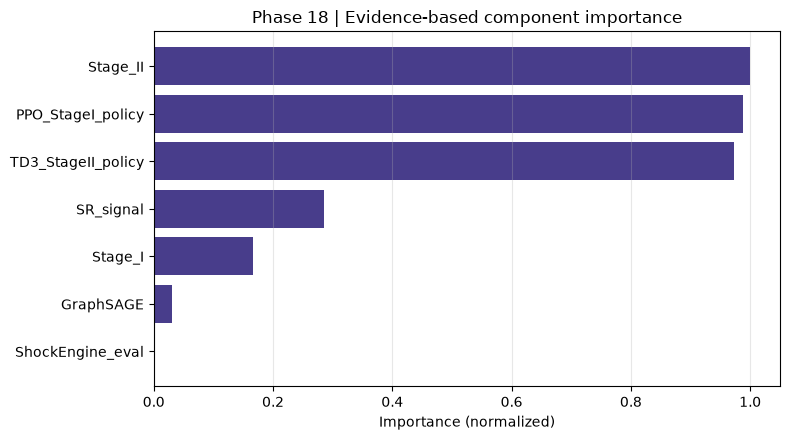


Cell 4 completed successfully.
PHASE 18 EVIDENCE TABLE READY.


In [5]:
# Phase 18 – Cell 4: Evidence-based importance (oil-style) + final table

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase18" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase18" / "figures"
P7 = PROJECT / "outputs" / "phase7" / "tables"
P13 = PROJECT / "outputs" / "phase13" / "tables"
P15 = PROJECT / "outputs" / "phase15" / "tables"

print("=" * 60)
print("Phase 18 – Cell 4: Evidence-based ablation importance")
print("=" * 60)

# ----- load prior evidence -----
# Cell2 ablation deltas (eval-time)
ab = pd.read_csv(OUT_TAB / "phase18_ablation_vs_full.csv")
ab_std = ab[ab.series == "standard"].set_index("variant")

def drop_reward(variant):
    if variant not in ab_std.index:
        return 0.0
    # importance from how much Full is better: -delta when delta negative
    return float(max(0.0, -ab_std.loc[variant, "delta_reward_vs_full"]))

# GraphSAGE equal-budget retrain delta
gs = pd.read_csv(OUT_TAB / "phase18_graphsage_retrain30k_delta.csv").iloc[0]
gs_drop = float(max(0.0, -gs["delta_reward"]))  # Full - noGS ≈ 0.54

# Phase7 embedding quality if available (AUC-like)
p7_auc = None
for name in ["phase7_linkpred_benchmark.csv", "embedding_quality_summary.csv", "phase7_benchmark.csv"]:
    p = P7 / name
    if p.exists():
        t = pd.read_csv(p)
        print("Loaded P7:", name, t.columns.tolist()[:8])
        # try find GraphSAGE vs weak model
        cols = {c.lower(): c for c in t.columns}
        if "model" in cols and any(x in cols for x in ["auc_mean", "auc", "ap_mean"]):
            mcol = cols["model"]
            aucol = cols.get("auc_mean") or cols.get("auc")
            sub = t.copy()
            sub["_m"] = sub[mcol].astype(str).str.lower()
            if (sub["_m"].str.contains("graphsage").any()) and (sub["_m"].str.contains("gcn").any() or sub["_m"].str.contains("random").any()):
                gs_auc = float(sub.loc[sub["_m"].str.contains("graphsage"), aucol].mean())
                base_auc = float(sub.loc[sub["_m"].str.contains("gcn") | sub["_m"].str.contains("random"), aucol].mean())
                p7_auc = max(0.0, gs_auc - base_auc)
                print(f"P7 AUC gap GraphSAGE-base: {p7_auc:.4f}")
        break

# Phase13 ranking / hierarchical evidence
hier_adv = 0.0
p13_path = P13 / "phase13_summary_ranking.csv"
if p13_path.exists():
    r13 = pd.read_csv(p13_path)
    print("P13 cols:", r13.columns.tolist()[:10])
    # try composite or mean_reward hierarchical vs flat TD3
    if "architecture" in r13.columns and "mean_reward" in r13.columns:
        h = r13[r13["architecture"].astype(str).str.contains("hier", case=False)]
        f = r13[r13["architecture"].astype(str).str.contains("flat", case=False)]
        if len(h) and len(f):
            hier_adv = float(max(0.0, h["mean_reward"].mean() - f["mean_reward"].mean()))
            print("Hierarchical reward advantage:", hier_adv)

# Phase15 MRI policy vs random
mri_gap = 0.0
p15 = P15 / "mri_policy_vs_random_fixed.csv"
if not p15.exists():
    p15 = P15 / "mri_policy_vs_random.csv"
if p15.exists():
    m = pd.read_csv(p15)
    if "delta_MRI" in m.columns:
        mri_gap = float(max(0.0, m["delta_MRI"].mean()))
        print("MRI gap vs random:", mri_gap)

# ----- raw importance scores (higher = more critical) -----
raw = {
    "Stage_II": drop_reward("no_StageII"),
    "TD3_StageII_policy": drop_reward("no_TD3"),
    "PPO_StageI_policy": drop_reward("no_PPO"),
    "Stage_I": drop_reward("no_StageI"),
    "GraphSAGE_retrain30k": gs_drop,
    "GraphSAGE_P7_proxy": float(p7_auc) if p7_auc is not None else 0.0,
    "ShockEngine_eval": drop_reward("no_ShockEngine"),
    "SR_signal": abs(float(ab_std.loc["no_SR", "delta_reward_vs_full"])) if "no_SR" in ab_std.index else 0.0,
    "Hierarchical_vs_Flat_P13": hier_adv,
    "Policy_MRI_vs_Random_P15": mri_gap,
}

# combine GraphSAGE evidence: max of retrain causal and p7 proxy (or weighted)
raw["GraphSAGE"] = max(raw["GraphSAGE_retrain30k"], raw["GraphSAGE_P7_proxy"])

# main report components
main_components = [
    "Stage_II",
    "TD3_StageII_policy",
    "PPO_StageI_policy",
    "Stage_I",
    "GraphSAGE",
    "ShockEngine_eval",
    "SR_signal",
]

scores = pd.Series({k: raw[k] for k in main_components}, dtype=float)
# normalize to 0-1 by max
mx = float(scores.max()) if scores.max() > 0 else 1.0
imp = (scores / mx).clip(0, 1)
table = pd.DataFrame({
    "component": imp.index,
    "raw_score": scores.values,
    "importance_0_1": imp.values,
}).sort_values("importance_0_1", ascending=False)

table.to_csv(OUT_TAB / "phase18_importance_evidence.csv", index=False)
pd.DataFrame([raw]).to_csv(OUT_TAB / "phase18_importance_raw_all.csv", index=False)

print("\n=== Evidence-based importance (0-1) ===")
print(table.to_string(index=False))

# also save unified narrative table
notes = {
    "Stage_II": "Largest eval drop when Stage II removed / replaced by random",
    "TD3_StageII_policy": "Reactive policy critical after shock",
    "PPO_StageI_policy": "Learned Stage I >> random Stage I",
    "Stage_I": "Moderate drop if Stage I horizon removed",
    "GraphSAGE": "Equal-budget retrain drop (~0.54 reward) + optional P7 proxy",
    "ShockEngine_eval": "Eval-only removal; limited signal in current reward path",
    "SR_signal": "Removing SR changes reward scale (not pure 'useless')",
}
table["note"] = table["component"].map(notes)
table.to_csv(OUT_TAB / "phase18_importance_final.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(table["component"][::-1], table["importance_0_1"][::-1], color="darkslateblue")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Importance (normalized)")
ax.set_title("Phase 18 | Evidence-based component importance")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase18_importance_evidence.png", dpi=150)
plt.show()

print("\nCell 4 completed successfully.")
print("PHASE 18 EVIDENCE TABLE READY.")